<a href="https://colab.research.google.com/github/subhashiitb/CodeBasics/blob/main/ML/LR-Example/9_decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2 style='color:blue' align="center">Decision Tree Classification</h2>

In [69]:
import pandas as pd

In [70]:
url='https://raw.githubusercontent.com/subhashiitb/CodeBasics/refs/heads/main/ML/LR-Example/salaries.csv'
df = pd.read_csv(url)
df.head()

,company,job,degree,salary_more_then_100k
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0


In [71]:
inputs = df.drop('salary_more_then_100k',axis='columns')

In [72]:
target = df['salary_more_then_100k']

In [73]:
from sklearn.preprocessing import LabelEncoder
le_company = LabelEncoder()
le_job = LabelEncoder()
le_degree = LabelEncoder()

In [74]:
le_company
le_job
le_degree

LabelEncoder()

In [75]:
inputs['company_n'] = le_company.fit_transform(inputs['company'])
inputs['job_n'] = le_job.fit_transform(inputs['job'])
inputs['degree_n'] = le_degree.fit_transform(inputs['degree'])

In [18]:
inputs

,company,job,degree,company_n,job_n,degree_n
0,google,sales executive,bachelors,2,2,0
1,google,sales executive,masters,2,2,1
2,google,business manager,bachelors,2,0,0
3,google,business manager,masters,2,0,1
4,google,computer programmer,bachelors,2,1,0
5,google,computer programmer,masters,2,1,1
6,abc pharma,sales executive,masters,0,2,1
7,abc pharma,computer programmer,bachelors,0,1,0
8,abc pharma,business manager,bachelors,0,0,0
9,abc pharma,business manager,masters,0,0,1


In [19]:
inputs_n = inputs.drop(['company','job','degree'],axis='columns')

In [20]:
inputs_n

,company_n,job_n,degree_n
0,2,2,0
1,2,2,1
2,2,0,0
3,2,0,1
4,2,1,0
5,2,1,1
6,0,2,1
7,0,1,0
8,0,0,0
9,0,0,1


In [21]:
target

,salary_more_then_100k
0,0
1,0
2,1
3,1
4,0
5,1
6,0
7,0
8,0
9,1


In [22]:
from sklearn import tree
model = tree.DecisionTreeClassifier()

In [27]:
model.fit(inputs_n, target)

DecisionTreeClassifier()

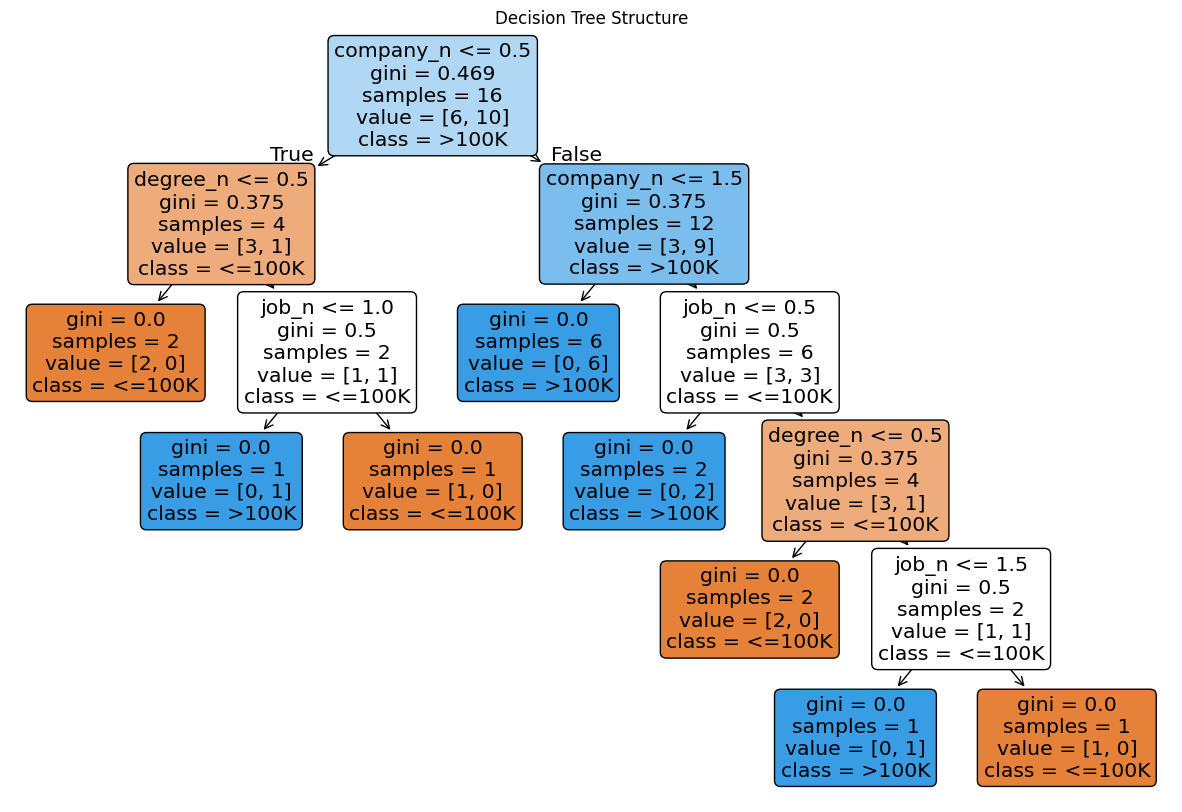

In [32]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(15,10))
tree.plot_tree(model,
               feature_names=inputs_n.columns,  # Use column names from inputs_n as feature names
               class_names=['<=100K', '>100K'], # Assuming 0 is <=100K and 1 is >100K
               filled=True,
               rounded=True)
plt.title("Decision Tree Structure")
plt.show()

In [33]:
model.score(inputs_n,target)

1.0

**Is salary of Google, Computer Engineer, Bachelors degree > 100 k ?**

In [25]:
model.predict([[2,1,0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

**Is salary of Google, Computer Engineer, Masters degree > 100 k ?**

In [26]:
model.predict([[2,1,1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

**Exercise: Build decision tree model to predict survival based on certain parameters**

<img src="https://github.com/subhashiitb/CodeBasics/blob/main/ML/LR-Example/titanic.jpg?raw=1" height=200 width=400/>

CSV file is available to download at https://github.com/codebasics/py/blob/master/ML/9_decision_tree/Exercise/titanic.csv

##### In this file using following columns build a model to predict if person would survive or not,

1. Pclass
1. Sex
1. Age
1. Fare

##### Calculate score of your model

In [108]:
url1 = 'https://raw.githubusercontent.com/subhashiitb/CodeBasics/refs/heads/main/ML/LR-Example/titanic.csv'

In [109]:
df =pd.read_csv(url1)

In [110]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [111]:
df_new = df[['Pclass','Sex','Age','Fare']]

In [112]:
target_new = df['Survived']

In [113]:
df_new

,Pclass,Sex,Age,Fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500
...,...,...,...,...
886,2,male,27.0,13.0000
887,1,female,19.0,30.0000
888,3,female,NaN,23.4500
889,1,male,26.0,30.0000


In [114]:
target_new

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [115]:
from sklearn.preprocessing import LabelEncoder
le_Sex = LabelEncoder()

In [116]:
df_new.loc[:, 'Sex_new'] = le_Sex.fit_transform(df_new['Sex'])

/tmp/ipykernel_2584/2840338692.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new.loc[:, 'Sex_new'] = le_Sex.fit_transform(df_new['Sex'])


In [117]:
df_new

,Pclass,Sex,Age,Fare,Sex_new
0,3,male,22.0,7.2500,1
1,1,female,38.0,71.2833,0
2,3,female,26.0,7.9250,0
3,1,female,35.0,53.1000,0
4,3,male,35.0,8.0500,1
...,...,...,...,...,...
886,2,male,27.0,13.0000,1
887,1,female,19.0,30.0000,0
888,3,female,NaN,23.4500,0
889,1,male,26.0,30.0000,1


In [118]:
df_new = df_new.drop(['Sex'],axis='columns')

In [119]:
print(df_new.isnull().sum())

Pclass       0
Age        177
Fare         0
Sex_new      0
dtype: int64


In [120]:
df_new

,Pclass,Age,Fare,Sex_new
0,3,22.0,7.2500,1
1,1,38.0,71.2833,0
2,3,26.0,7.9250,0
3,1,35.0,53.1000,0
4,3,35.0,8.0500,1
...,...,...,...,...
886,2,27.0,13.0000,1
887,1,19.0,30.0000,0
888,3,NaN,23.4500,0
889,1,26.0,30.0000,1


In [121]:
df_new.Age = df_new.Age.fillna(df_new.Age.mean())
print(df_new.isnull().sum())

Pclass     0
Age        0
Fare       0
Sex_new    0
dtype: int64


In [122]:
display(df_new.head())

,Pclass,Age,Fare,Sex_new
0,3,22.0,7.2500,1
1,1,38.0,71.2833,0
2,3,26.0,7.9250,0
3,1,35.0,53.1000,0
4,3,35.0,8.0500,1


In [123]:
from sklearn import tree
model = tree.DecisionTreeClassifier()

In [125]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_new,target_new,test_size=0.2)

In [90]:
model.fit(df_new, target_new)

DecisionTreeClassifier()

In [126]:
len(X_train)

712

In [129]:
len(X_test)

179

In [145]:
from sklearn.metrics.cluster import entropy
from sklearn import tree
model = tree.DecisionTreeClassifier(max_depth=3,criterion='gini')

In [146]:
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3)

In [147]:
model.score(X_test,y_test)

0.7932960893854749

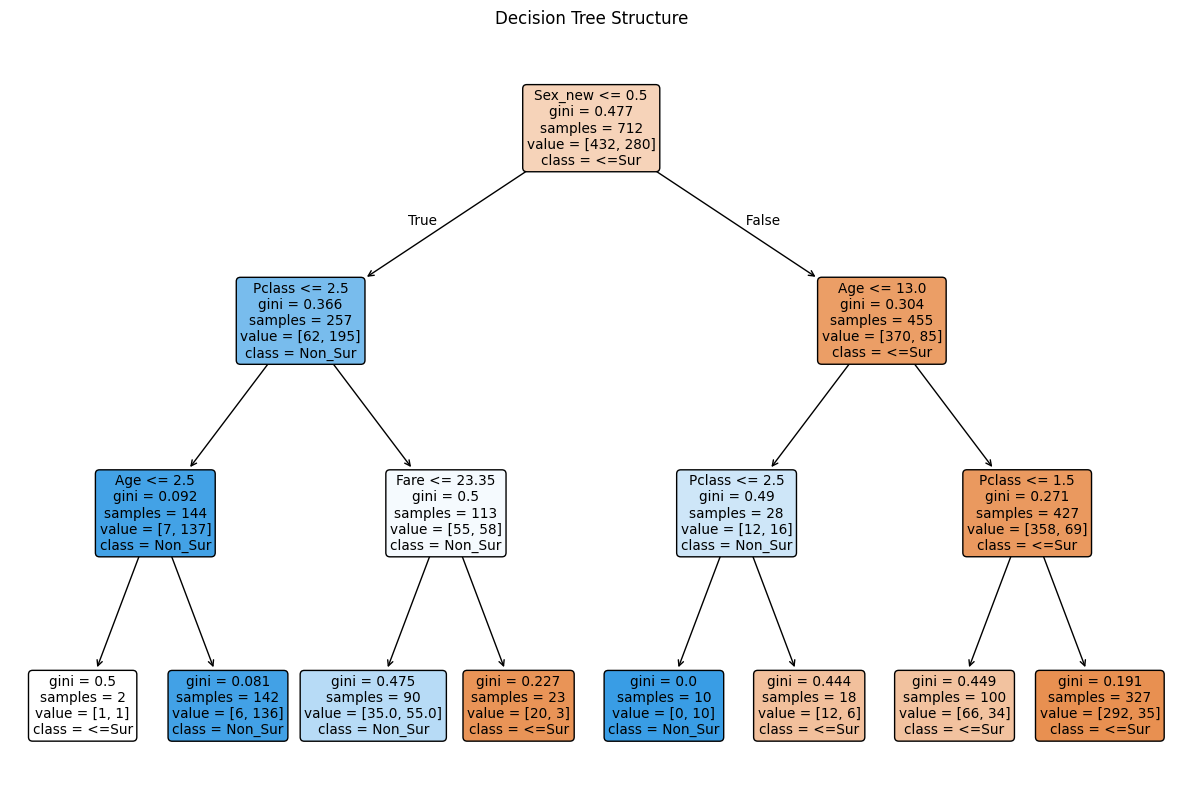

In [148]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(15,10))
tree.plot_tree(model,
               feature_names=df_new.columns,  # Use column names from inputs_n as feature names
               class_names=['<=Sur', 'Non_Sur'], # Assuming 0 is <=100K and 1 is >100K
               filled=True,
               rounded=True)
plt.title("Decision Tree Structure")
plt.show()